In [1]:
import pandas as pd
import sys                          
import numpy as np             # Data manipulation 
from sklearn.decomposition import PCA        # The main algorithm
from matplotlib import pyplot as plt         # Graphing
import seaborn as sns                        # Graphing
from collections import defaultdict, Counter # Utils
sns.set(style="white")                       # Tuning the style of charts
import warnings                              # Disable some warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)

In [2]:
data_factorySolarGen = pd.read_csv('Generacion_fotovoltaica.csv')
data_gridInput = pd.read_csv('Consumo.csv')
data_Weather = pd.read_csv('Meteorologia.csv')
data_CarbonIntensity23 = pd.read_csv('ES_2023_hourly.csv')
data_CarbonIntensity24 = pd.read_csv('ES_2024_hourly.csv')
data_CarbonIntensity = pd.concat([data_CarbonIntensity23, data_CarbonIntensity24], ignore_index=True)
data_factorySolarUse = pd.read_csv('Consumo_fotovoltaica.csv')

In [3]:
def renameAndIndex(df,datetime):
    df=df.rename(columns={datetime:'TIMESTAMP'})
    df['TIMESTAMP']=pd.to_datetime(df['TIMESTAMP'])
    df.set_index('TIMESTAMP', inplace=True)
    return df

In [4]:
data_factorySolarGen = renameAndIndex(data_factorySolarGen,'FECHA')
data_gridInput = renameAndIndex(data_gridInput,'FECHA')
data_Weather = renameAndIndex(data_Weather,'FORECAST_TIMESTAMP')
data_CarbonIntensity = renameAndIndex(data_CarbonIntensity,'Datetime (UTC)')
data_factorySolarUse = renameAndIndex(data_factorySolarUse,'FECHA')

In [5]:
allDatasets = {
    "factorySolarGen": data_factorySolarGen,
    "gridInput": data_gridInput,
    "weather": data_Weather,
    "carbonIntensity": data_CarbonIntensity,
    "factorySolarUse": data_factorySolarUse
}

minMaxDates = {}
for name, dataset in allDatasets.items():
    min_date = dataset.index.min()
    max_date = dataset.index.max()
    dataLen = len(dataset)
    minMaxDates[name] = {"min": min_date, "max": max_date, "rows":dataLen}

timeframes = pd.DataFrame(minMaxDates)

timeframes


,factorySolarGen,gridInput,weather,carbonIntensity,factorySolarUse
min,2023-07-24 11:00:00,2023-07-24 11:00:00,2023-07-24 11:00:00+00:00,2023-01-01 00:00:00,2024-09-01 00:00:00+02:00
max,2024-08-31 23:00:00,2024-08-31 23:00:00,2024-10-31 23:00:00+00:00,2024-12-31 23:00:00,2024-10-17 23:00:00+02:00
rows,9708,9708,100557,17544,1128


In [6]:
coords = data_Weather[['LATITUDE', 'LONGITUDE']].drop_duplicates().values.tolist()
coords

# Since the weather data is collected from 9 distinct points, according to the EDA, we can average these 9 points to get an accurate reading, as we don't know exact factory location

data_Weather.groupby('TIMESTAMP').mean()

,LATITUDE,LONGITUDE,10uheightAboveGround_10,10vheightAboveGround_10,2rheightAboveGround_2,2shheightAboveGround_2,2theightAboveGround_2,SUNSDsurface_0,aptmpheightAboveGround_2,dlwrfsurface_0,...,spsurface_0,tccatmosphere_0,theightAboveGround_80,tmaxheightAboveGround_2,tminheightAboveGround_2,tozneatmosphereSingleLayer_0,tpsurface_0,tsurface_0,uheightAboveGround_80,vheightAboveGround_80
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2023-07-24 11:00:00+00:00,40.25,-3.75,5.176383,2.306685,17.577778,0.004644,301.823414,18000.0,300.332920,320.641024,...,94006.964236,2.700000,299.178662,301.843240,293.290378,324.906396,0.000000,315.466679,5.985768,2.433457
2023-07-24 12:00:00+00:00,40.25,-3.75,5.670802,2.579575,16.988889,0.004856,303.187798,21600.0,301.359812,324.429913,...,93949.704861,3.800000,300.411111,303.219008,293.290378,325.770036,0.000000,317.400000,6.652786,2.790844
2023-07-24 13:00:00+00:00,40.25,-3.75,6.260587,2.442148,17.077778,0.005225,304.332392,3600.0,302.303198,352.366667,...,93885.935417,38.833333,301.517803,304.326211,303.222222,326.296606,0.000000,318.032850,7.447305,2.665181
2023-07-24 14:00:00+00:00,40.25,-3.75,7.004427,2.025345,17.266667,0.005513,305.103729,7200.0,302.988475,356.926508,...,93829.203819,23.177778,302.366265,305.123018,303.222222,327.157633,0.000000,317.471498,8.407716,2.233926
2023-07-24 15:00:00+00:00,40.25,-3.75,7.471493,2.054768,17.411111,0.005703,305.553950,10800.0,303.401274,360.544444,...,93770.919444,58.177778,303.032275,305.617803,303.222222,330.289266,0.000000,315.935266,8.912477,2.333355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-31 19:00:00+00:00,40.25,-3.75,1.712167,-0.120578,73.222222,0.008330,288.451378,0.0,288.458230,332.734110,...,94665.164583,42.044444,288.438051,289.342572,288.244711,295.169328,0.013889,287.852675,2.547099,0.112466
2024-10-31 20:00:00+00:00,40.25,-3.75,1.172493,0.060525,75.133333,0.008365,288.053681,0.0,288.046803,326.544554,...,94687.728819,54.911111,288.217674,289.467016,287.635614,295.584785,0.013889,287.270662,1.844787,0.230565
2024-10-31 21:00:00+00:00,40.25,-3.75,0.838918,0.100157,74.722222,0.008353,288.091836,0.0,288.100517,328.326836,...,94711.029167,71.344444,288.150030,289.579238,287.398305,295.179774,0.013889,287.248275,1.417429,0.248963


In [7]:
from geopy.distance import geodesic  # accurate distance calculation

repsolPintoCoords = [40.265468,3.738145] # Solar installation location from GMaps

grid_coords = coords
target_coord = repsolPintoCoords

distances = [geodesic(coord, target_coord).kilometers for coord in grid_coords]

inv_distances = [1/d if d != 0 else 1e9 for d in distances]  # Avoid division by zero
total = sum(inv_distances)
weights = [w/total for w in inv_distances]

point_names = [f"point{i+1}" for i in range(len(grid_coords))]
weight_mapping = dict(zip(point_names, weights))

In [8]:
point_labels = [f"point{i+1}" for i in range(len(coords))]

coord_to_label = {tuple(coord): label for coord, label in zip(coords, point_labels)}

data_Weather['point'] = data_Weather[['LATITUDE', 'LONGITUDE']].apply(
    lambda row: coord_to_label.get((row['LATITUDE'], row['LONGITUDE']), None),
    axis=1
)

data_Weather['weight'] = data_Weather['point'].map(weight_mapping)

columns_to_weight = [col for col in data_Weather.columns if col not in ['LATITUDE', 'LONGITUDE','point']]

for col in columns_to_weight:
    data_Weather[col] = data_Weather[col] * data_Weather['weight']

data_Weather = data_Weather.drop(columns=['point','weight','LATITUDE','LONGITUDE'])

data_Weather = data_Weather.groupby('TIMESTAMP').sum()

data_Weather.index = data_Weather.index.tz_convert(None)

In [9]:
data_All = pd.concat([
    data_factorySolarGen.add_prefix("SG_"),
    data_gridInput.add_prefix("GI_"),
    data_Weather.add_prefix("W_")
], axis=1, join='inner')

In [10]:
data_All.isna().mean().sort_values(ascending=False)*100

SG_TOTAL_KWH_ENERGIA              11.990111
GI_TOTAL_KWH_ENERGIA               0.144211
W_uheightAboveGround_80            0.000000
W_tsurface_0                       0.000000
W_tpsurface_0                      0.000000
W_tozneatmosphereSingleLayer_0     0.000000
W_tminheightAboveGround_2          0.000000
W_tmaxheightAboveGround_2          0.000000
W_theightAboveGround_80            0.000000
W_tccatmosphere_0                  0.000000
W_spsurface_0                      0.000000
W_qheightAboveGround_80            0.000000
W_pwatatmosphereSingleLayer_0      0.000000
W_presheightAboveGround_80         0.000000
W_msletmeanSea_0                   0.000000
W_gustsurface_0                    0.000000
W_dswrfsurface_0                   0.000000
W_dlwrfsurface_0                   0.000000
W_aptmpheightAboveGround_2         0.000000
W_SUNSDsurface_0                   0.000000
W_2theightAboveGround_2            0.000000
W_2shheightAboveGround_2           0.000000
W_2rheightAboveGround_2         

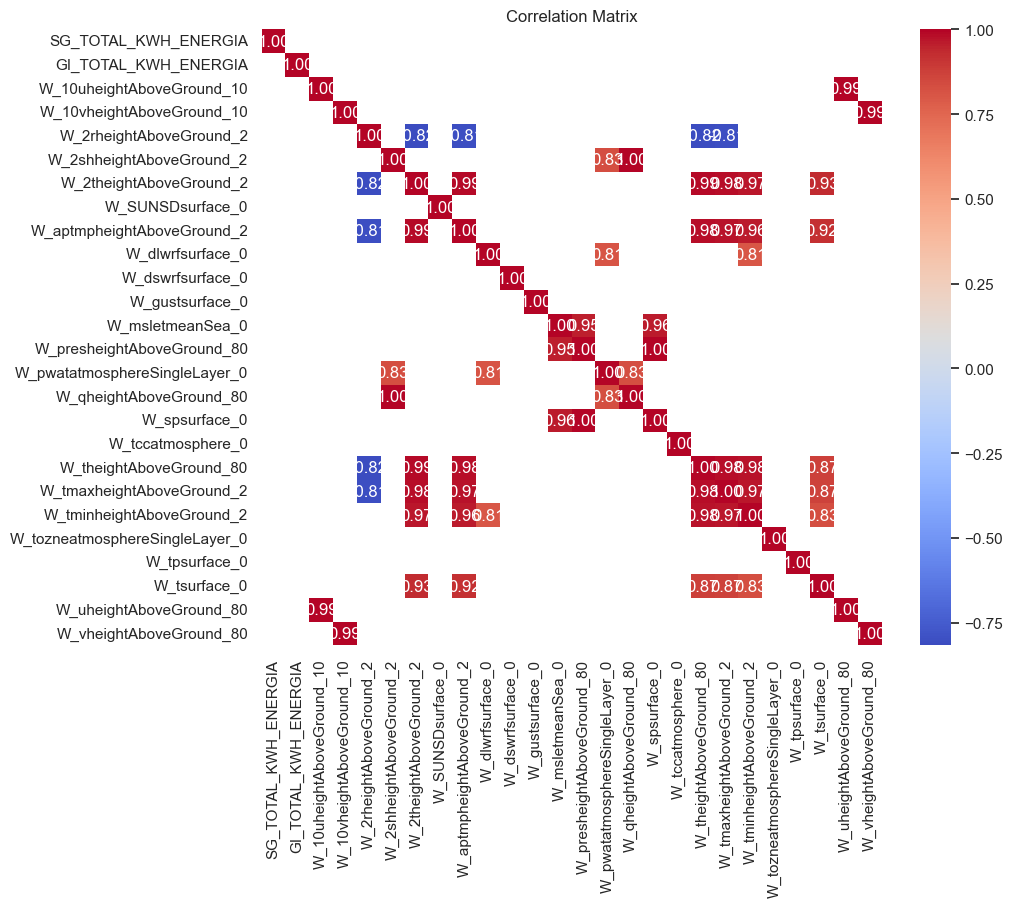

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = data_All.corr()
filtered_corr = correlation_matrix[correlation_matrix.abs() > 0.8]
plt.figure(figsize=(10, 8))
sns.heatmap(filtered_corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Principal Component Analysis

### Null Imputation

In [12]:
import numpy as np

numerical_columns = list(data_All.select_dtypes(include=[np.number]).columns)

impute = True # you can change this

if impute:
    # Use mean for numerical features
    for feature in data_All:
        v = data_All[feature].mean()
        if np.isnan(v):
            v = 0
        print("Filling %s with %s" % (feature, v))
        data_All[feature] = data_All[feature].fillna(v)

else:        
    # drop records
    data_All.dropna(inplace=True)

Filling SG_TOTAL_KWH_ENERGIA with 25.395278558052432
Filling GI_TOTAL_KWH_ENERGIA with 204.51042321475296
Filling W_10uheightAboveGround_10 with 1.3021894339378584
Filling W_10vheightAboveGround_10 with 0.4429861557820012
Filling W_2rheightAboveGround_2 with 50.57990573793787
Filling W_2shheightAboveGround_2 with 0.006208356537431647
Filling W_2theightAboveGround_2 with 290.94248247676086
Filling W_SUNSDsurface_0 with 6178.467455208005
Filling W_aptmpheightAboveGround_2 with 290.16934378306007
Filling W_dlwrfsurface_0 with 323.2102952167248
Filling W_dswrfsurface_0 with 210.42779214653933
Filling W_gustsurface_0 with 5.382198286131842
Filling W_msletmeanSea_0 with 101585.22085939063
Filling W_presheightAboveGround_80 with 93479.85078133739
Filling W_pwatatmosphereSingleLayer_0 with 16.569260924550722
Filling W_qheightAboveGround_80 with 0.006034839595974294
Filling W_spsurface_0 with 94357.31189350307
Filling W_tccatmosphere_0 with 44.55483082417675
Filling W_theightAboveGround_80 with

NameError: name 'categorical_columns' is not defined

In [18]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler().fit(data_All)
X_std = ss.transform(data_All)

#### Compute PCA

In [ ]:
sklearn_pca = PCA()
Y_sklearn = sklearn_pca.fit_transform(X_std)